# 01 · The bench

**The problem this project attacks.** Generative models are increasingly used
as priors inside scientific inference. A diffusion or flow model is trained on
simulations, then steered with data so that its samples follow a posterior
distribution over maps, images, or molecules. The steering methods in actual
use are approximations without guarantees, and on real data their output
cannot be checked, because checking would require the true posterior. That is
the thing being computed. So results ship with error bars nobody has verified,
and the diagnostics offered as verification have rarely been tested themselves.

**The move.** Build a world where the true posterior is known exactly, at the
scale where these methods actually operate (fields with thousands of
dimensions). Use it for two audits. First, measure how wrong each sampler
actually is, and why. Second, test the diagnostics themselves: force each one
to pass on a provably perfect sampler before it is allowed an opinion, then
show it constructed failures with exactly known damage and record what it
catches.

This notebook builds the bench and demonstrates its exactness. Notebook 02
covers the sampler anatomy, 03 puts the proposed certificates on trial, and
04 extends everything to a nonlinear substrate with MCMC gold standards.

## The construction, precisely

The prior is a Gaussian random field. In its Fourier basis it is a list of
independent Gaussians, one per spatial frequency $k$, with variances given by
a power spectrum:

$$z_k \sim \mathcal{N}\big(0,\, P(k)\big), \qquad
P(k) \propto \max(k,1)^{n_s-4}\, e^{-(k/k_c)^2}.$$

**In words:** each spatial scale fluctuates independently, large scales
(small $k$) fluctuate strongly and small scales weakly, the way cosmological
matter fields do. The observation applies a smoothing operator $A$ (diagonal
in the same basis, entries $a_k$) and adds white noise of standard deviation
$s$. Steering the prior toward data $y$ means targeting

$$\sigma(x) \;\propto\; p(x)\, e^{r(x)/\beta}, \qquad
r(x) = -\tfrac{1}{2 s^2}\|Ax - y\|^2 .$$

**In words:** weight every prior map by how well it explains the data, with
$\beta$ setting how hard the data pull. For this family the target is the
classical Wiener posterior, again independent per mode, with closed-form mean
and variance:

$$\Sigma^*_k = \Big(\tfrac{1}{P(k)} + \tfrac{a_k^2}{b}\Big)^{-1},
\qquad \mu^*_k = \Sigma^*_k\, \frac{a_k\, y_k}{b},
\qquad b = \beta s^2 .$$

**In words:** where the instrument sees well ($a_k$ large relative to noise)
the posterior follows the data and its variance shrinks far below the prior.
Where the instrument is blind, the posterior falls back to the prior. Every
quantity this project measures against (the score, the diffusion marginals,
the optimal twist, distances like $W_2$ and KL, the null of every diagnostic)
follows from these two formulas in closed form, at any size.

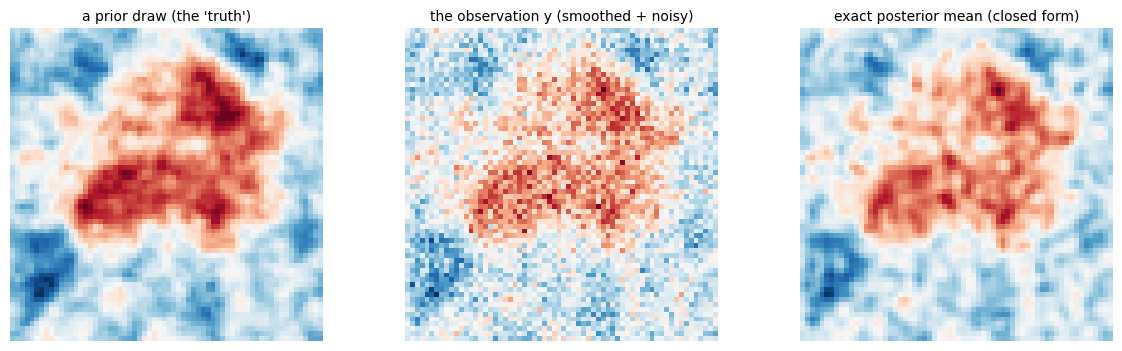

dimensions: 4096, steering strength b = 0.01914


In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

from tilt_audit import tilt
from tilt_audit.fields import (grid_to_z, make_basis, make_pk,
                               smoothing_operator, unpack)
import jax
import jax.numpy as jnp

n = 64
basis = make_basis(n)
Pz = jnp.asarray(grid_to_z(make_pk(basis), basis))
az = jnp.asarray(smoothing_operator(basis))
y, z_truth = tilt.make_observation(jax.random.PRNGKey(999), Pz, az, 0.5)
b = float(tilt.calibrate_b(Pz, az, y, target_shift=1.0))
mu, Sig = tilt.posterior_params(Pz, az, y, b)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, field, title in [
        (axes[0], unpack(z_truth, basis), "a prior draw (the 'truth')"),
        (axes[1], unpack(y, basis), "the observation y (smoothed + noisy)"),
        (axes[2], unpack(mu, basis), "exact posterior mean (closed form)")]:
    ax.imshow(np.asarray(field), cmap="RdBu_r")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"dimensions: {int(Pz.shape[0])}, steering strength b = {b:.4g}")

**Reading the panels.** Left: one random map the prior considers
plausible. Middle: what the instrument records of it, blurred by $A$ and
buried in noise at small scales. Right: the exact posterior mean, which
recovers structure exactly where the data support it and smooths away what
the noise has destroyed.

The next figure shows the same statement in frequency space, which is where
this bench does all its accounting.

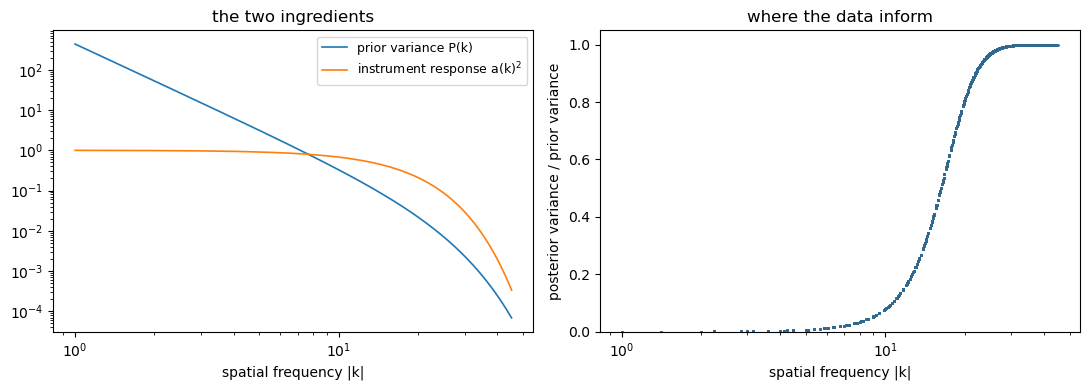

most informed mode: posterior variance shrunk to 0.000 of the prior
fraction of modes where data cut the variance by half or more: 0.20


In [2]:
kz = grid_to_z(basis.kmag, basis)
order = np.argsort(kz)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.loglog(kz[order][1:], np.asarray(Pz)[order][1:], lw=1.2,
          label="prior variance P(k)")
ax.loglog(kz[order][1:], np.asarray(az)[order][1:] ** 2, lw=1.2,
          label="instrument response a(k)$^2$")
ax.set_xlabel("spatial frequency |k|")
ax.set_title("the two ingredients")
ax.legend(fontsize=9)

ax = axes[1]
ratio = np.asarray(Sig) / np.asarray(Pz)
ax.semilogx(kz[order][1:], ratio[order][1:], ".", ms=2, color="#31688e")
ax.set_xlabel("spatial frequency |k|")
ax.set_ylabel("posterior variance / prior variance")
ax.set_ylim(0, 1.05)
ax.set_title("where the data inform")
plt.tight_layout()
plt.show()
print(f"most informed mode: posterior variance shrunk to "
      f"{ratio.min():.3f} of the prior")
print(f"fraction of modes where data cut the variance by half or more: "
      f"{np.mean(ratio < 0.5):.2f}")

**Reading the right panel.** Each dot is one of the 4,096 modes. A value
of 1 means the data taught the posterior nothing about that mode, a value near
0 means the data pinned it. The transition happens where the instrument
response falls below the noise. Sampler failures live in exactly this
geometry: a biased sampler typically gets the well-informed modes roughly
right and quietly mis-states the transition region, which is why this project
reports per-band numbers throughout.

## Steering strength, calibrated not guessed

Comparisons across settings need a physical scale for "how hard did the data
pull". We use the root-mean-square shift of the posterior mean away from the
prior mean, measured in units of the prior standard deviation, and we solve
for the $b$ that produces a requested shift:

$$\mathrm{shift}(b) = \sqrt{\tfrac{1}{d}\textstyle\sum_k
\mu^{*2}_k(b) / P(k)} .$$

**In words:** a shift of 1 means the data moved the answer by about one prior
sigma, a strong but realistic pull. The project's standard grid uses shifts
of 0.5, 1, 2, and 4.

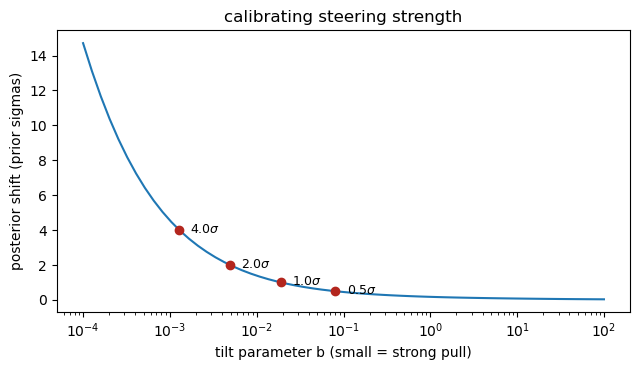

In [3]:
bs = np.geomspace(1e-4, 1e2, 60)
shifts = [float(tilt.rms_shift(Pz, az, y, float(bb))) for bb in bs]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogx(bs, shifts, lw=1.5)
for target in (0.5, 1.0, 2.0, 4.0):
    bcal = float(tilt.calibrate_b(Pz, az, y, target_shift=target))
    ax.plot([bcal], [target], "o", color="#b3261e")
    ax.annotate(f"{target}$\sigma$", (bcal, target),
                textcoords="offset points", xytext=(8, -2), fontsize=9)
ax.set_xlabel("tilt parameter b (small = strong pull)")
ax.set_ylabel("posterior shift (prior sigmas)")
ax.set_title("calibrating steering strength")
plt.tight_layout()
plt.show()

## Error bars of zero

The payoff of the closed forms: the distance between any Gaussian sampler
output and the truth is itself a formula. For diagonal Gaussians the squared
Wasserstein-2 distance decomposes per mode:

$$W_2^2 = \sum_k \Big[(m_k - \mu^*_k)^2 +
\big(\sqrt{v_k} - \sqrt{\Sigma^*_k}\big)^2\Big].$$

**In words:** a mean-error term plus a width-error term, per mode, summed.
The demonstration below builds a deliberately broken sampler (all posterior
widths inflated by 30%), computes its exact damage from the formula, and
shows the empirical estimate converging to that exact value as the sample
budget grows. On this bench, "how wrong is the sampler" is not itself an
estimate with error bars. It is a number.

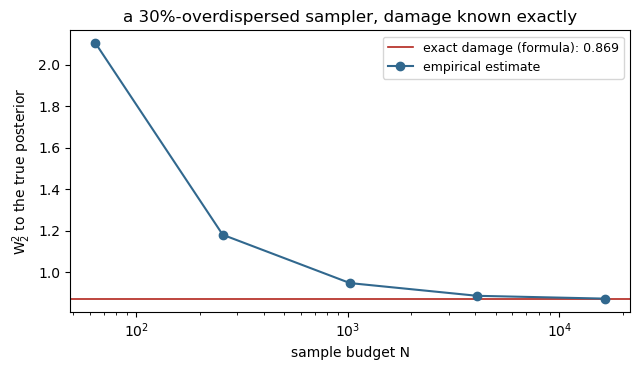

In [4]:
infl = 1.3
w2_exact = float(np.sum((np.sqrt(infl) - 1.0) ** 2 * np.asarray(Sig)))
Ns = [64, 256, 1024, 4096, 16384]
est = []
for N in Ns:
    k = jax.random.PRNGKey(N)
    zz = np.asarray(mu)[None] + np.sqrt(infl * np.asarray(Sig))[None] \
         * np.asarray(jax.random.normal(k, (N, int(Pz.shape[0]))))
    m_hat, v_hat = zz.mean(0), zz.var(0)
    est.append(float(np.sum((m_hat - np.asarray(mu)) ** 2
               + (np.sqrt(v_hat) - np.sqrt(np.asarray(Sig))) ** 2)))
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.axhline(w2_exact, color="#b3261e", lw=1.2,
           label=f"exact damage (formula): {w2_exact:.3f}")
ax.plot(Ns, est, "o-", color="#31688e", label="empirical estimate")
ax.set_xscale("log")
ax.set_xlabel("sample budget N")
ax.set_ylabel("W$_2^2$ to the true posterior")
ax.set_title("a 30%-overdispersed sampler, damage known exactly")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## The null-gate discipline

The same exactness disciplines the diagnostics. Before any test is allowed to
judge a sampler in this project, it must pass a null gate: run it on the
oracle (exact draws from the closed-form posterior) and require the nominal
false-alarm behavior. A test that flags a provably perfect sampler is broken,
whatever else it claims. This rule found real problems in released tools
during the project, and every instrument in notebooks 02 and 03 passed
through it first. Here is the gate for the bench itself.

In [5]:
from tilt_audit import samplers

res = samplers.oracle(jax.random.PRNGKey(0), Pz, az, y, b, N=4096, T=1, tf=9.0)
z = np.asarray(res["z"])
zscores = (z.mean(0) - np.asarray(mu)) / np.sqrt(np.asarray(Sig) / z.shape[0])
vratio = z.var(0) / np.asarray(Sig)
print(f"per-mode mean z-scores: max |z| = {np.abs(zscores).max():.2f} "
      f"(expected < ~4.3 for {z.shape[1]} modes under pure noise)")
print(f"per-mode variance ratios: median = {np.median(vratio):.4f} "
      f"(expected 1.000 +- {np.sqrt(2/z.shape[0]):.3f})")

per-mode mean z-scores: max |z| = 3.89 (expected < ~4.3 for 4096 modes under pure noise)
per-mode variance ratios: median = 0.9986 (expected 1.000 +- 0.022)


Both numbers sit at their theoretical noise floors.

**Where the data live.** Every experiment appends rows to `results/*.jsonl`
with full configuration. Every figure regenerates from those files. The
prediction ledger (`RESEARCH_LOG.md`) holds the pre-registered expectations
for each experiment, frozen and pushed publicly before the runs, and scored
afterwards, misses included. Continue with notebook 02.